In [5]:
import pickle
import variables
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import osmnx as ox
from tqdm import tqdm
from typing import List, Dict, Tuple
from termcolor import cprint
from filter_custom_dataset import compute_jaccard_similarity
from generate_custom_dataset import load_graph

In [6]:
def calculate_optimality_gap(
    dataset: List[Dict[str, List[int]]],
    edge_id_to_edge_length: Dict[int, float],
    edge_id_to_edge_travel_time: Dict[int, float],
) -> Tuple[List[float], List[float]]:
    """Calculate optimality gap between historical paths and baselines (fastest, shortest) paths.

    Args:
        dataset (List[Dict[str, List[int]]]): The original dataset.
        edge_id_to_edge_length (Dict[int, float]): Dictionary mapping edge id to their respective length.
        edge_id_to_edge_travel_time (Dict[int, float]): Dictionary mapping edge id to their respective travel_time.

    Returns:
        Tuple[List[float], List[float]]: Tuple containing the results.
    """

    gap_fastest = []
    gap_shortest = []

    for path_collection in tqdm(
        dataset,
        total=len(dataset),
        desc="Calculating optimality gap distribution",
        dynamic_ncols=True,
    ):
        

        historical_path = path_collection["historical_path_edges"]
        fastest_path = path_collection["fastest_path_edges"]
        shortest_path = path_collection["shortest_path_edges"]
        
        if len(historical_path) < 5 or len(fastest_path) < 5 or len(shortest_path) < 5:
            continue

        historical_time = sum(edge_id_to_edge_travel_time[e] for e in historical_path)
        historical_length = sum(edge_id_to_edge_length[e] for e in historical_path)

        fastest_time = sum(edge_id_to_edge_travel_time[e] for e in fastest_path)
        shortest_length = sum(edge_id_to_edge_length[e] for e in shortest_path)
        
        if historical_length < 1000 or shortest_length < 1000:
            continue
        
        if historical_time < 600 or fastest_time < 600:
            continue
        
        time_gap = (historical_time - fastest_time) / fastest_time
        distance_gap = (historical_length - shortest_length) / shortest_length
        
        if time_gap > 2.0 or distance_gap > 2.0:
            continue
 
        if fastest_time > 0:
            gap_fastest.append((historical_time - fastest_time) / fastest_time)

        if shortest_length > 0:
            gap_shortest.append((historical_length - shortest_length) / shortest_length)

    gap_fastest.sort()
    gap_shortest.sort()

    return gap_fastest, gap_shortest

In [7]:
def calculate_dataset_jaccard_similarities(
    dataset: List[Dict[str, List[int]]],
    edge_id_to_edge_length: Dict[int, float],
    edge_id_to_edge_travel_time: Dict[int, float],
) -> Tuple[List[float], List[float]]:
    """
    Calculates the similarity threshold based on the distribution of the dataset.
    Finds the max similarity of the custom path to any baseline for each sample,
    and returns the value at the specified percentile.
    """
    similarities_fastest, similarities_shortest, similarities_baselines = [], [], []

    for path_collection in tqdm(
        dataset,
        total=len(dataset),
        desc="Calculating similarity distribution",
        dynamic_ncols=True,
    ):
        historical_path = path_collection["historical_path_edges"]
        fastest_path = path_collection["fastest_path_edges"]
        shortest_path = path_collection["shortest_path_edges"]
        
        if len(historical_path) < 5 or len(fastest_path) < 5 or len(shortest_path) < 5:
            continue

        sim_fastest = compute_jaccard_similarity(
            fastest_path, historical_path, edge_id_to_edge_travel_time
        )
        
        sim_shortest = compute_jaccard_similarity(
            shortest_path, historical_path, edge_id_to_edge_length
        )
        
        sim_baseline = compute_jaccard_similarity(shortest_path, fastest_path, edge_id_to_edge_length)

        # We care about the maximum similarity to ANY of the baselines
        similarities_fastest.append(sim_fastest)
        similarities_shortest.append(sim_shortest)
        similarities_baselines.append(sim_baseline)

    return similarities_fastest, similarities_shortest, similarities_baselines

In [9]:
custom_path_type = variables.path_type

# Load graph
try:
    graph = load_graph(fname=variables.PICKLED_GRAPH)
except Exception as e:
    cprint(f"FATAL: Could not load graph: {e}", "red")
    exit(1)


# edges_df = gpd.read_file(variables.EDGE_DATA)

edges_df = ox.graph_to_gdfs(graph, nodes=False)
edges_df = edges_df.reset_index()

edge_id_to_edge_length = {i: (row.length) for i, row in edges_df.iterrows()}
edge_id_to_edge_travel_time = {i: row.get("travel_time")for i, row in edges_df.iterrows()}


Loading graph...


/root/autodl-tmp/PathGPT/generate_custom_dataset.py:130: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  graph = pickle.load(f)


The number of edges with missing travel times found is 0
Graph loaded successfully!


In [8]:

# ===== TRAIN DATA =====
cprint("\n" + "=" * 50, "light_yellow")
cprint("PROCESSING TRAINING DATA", "light_yellow", attrs=["bold"])
cprint("=" * 50, "light_yellow")

train_data_filename = (f"train_data/{variables.path_type}/{variables.place_name}_data")

try:
    with open(train_data_filename, "rb") as f:
        augmented_train_data = pickle.load(f)
except FileNotFoundError:
    cprint(f"Train data not found at {train_data_filename}! Please run generate_custom_dataset.py first.", "red")
    exit(1)

cprint(f"Loaded {len(augmented_train_data)} training samples.", "cyan")


PROCESSING TRAINING DATA
Loaded 647879 training samples.


In [ ]:
paths_removed = 0
for path_collection in tqdm(
    augmented_train_data,
    total=len(augmented_train_data),
    desc="Removing short paths",
    dynamic_ncols=True,
):
    
    historical_path = path_collection["historical_path_edges"]
    fastest_path = path_collection["fastest_path_edges"]
    shortest_path = path_collection["shortest_path_edges"]
    
    if len(historical_path) < 5 or len(fastest_path) < 5 or len(shortest_path) < 5:
        paths_removed += 1
        continue

cprint(f"Filtered train data: {len(augmented_train_data)} → {len(augmented_train_data) -  paths_removed}","cyan",)

In [10]:
similarities_fastest, similarities_shortest, similarities_baseline = calculate_dataset_jaccard_similarities(
    augmented_train_data, 
    edge_id_to_edge_length=edge_id_to_edge_length, edge_id_to_edge_travel_time=edge_id_to_edge_travel_time
)

Calculating similarity distribution: 100%|██████████| 647879/647879 [00:21<00:00, 29607.41it/s]


In [11]:
gap_fastest, gap_shortest = calculate_optimality_gap(dataset=augmented_train_data, edge_id_to_edge_length=edge_id_to_edge_length, edge_id_to_edge_travel_time=edge_id_to_edge_travel_time)

Calculating optimality gap distribution: 100%|██████████| 647879/647879 [00:06<00:00, 102632.22it/s]


In [ ]:
plt.hist(
similarities_shortest,
bins=50,
density=True,
cumulative=True,
alpha=0.5,
color="blue",
)
plt.title("CDF of Maximum Jaccard Similarity to Baselines")
plt.xlabel("Jaccard Similarity Score")
plt.ylabel("Cumulative Proportion of Dataset")
plt.grid(True)
plt.show()


In [ ]:
plt.hist(
similarities_fastest,
bins=50,
density=True,
cumulative=True,
alpha=0.5,
color="blue",
)
plt.title("CDF of Maximum Jaccard Similarity to Baselines")
plt.xlabel("Jaccard Similarity Score")
plt.ylabel("Cumulative Proportion of Dataset")
plt.grid(True)
plt.show()


In [ ]:
sorted_gap = gap_shortest
cdf = np.arange(1, len(sorted_gap)+1) / len(sorted_gap)

plt.plot(sorted_gap, cdf)
plt.xlabel("Optimality Gap Shortest")
plt.ylabel(f"Cumulative Fraction of Trips From the {variables.place_name.capitalize()} Dataset.")
plt.title("CDF of Route Optimality Gap")
plt.grid(True)
plt.show()

In [ ]:
sorted_gap = gap_fastest
cdf = np.arange(1, len(sorted_gap)+1) / len(sorted_gap)

plt.plot(sorted_gap, cdf)
plt.xlabel("Optimality Gap Fastest")
plt.ylabel(f"Cumulative Fraction of Trips From the {variables.place_name.capitalize()} Dataset.")
plt.title("CDF of Route Optimality Gap")
plt.grid(True)
plt.show()

In [ ]:
jaccard_fastest = similarities_fastest
jaccard_shortest = similarities_shortest
jaccard_baseline = similarities_baseline


plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 10,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

sns.set_style("white")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.ecdfplot(data=jaccard_fastest, label='Historical vs. Fastest', 
             color='#D55E00', linewidth=2.5, ax=ax)
sns.ecdfplot(data=jaccard_shortest, label='Historical vs. Shortest', 
             color='#0072B2', linewidth=2.5, ax=ax)
sns.ecdfplot(data=similarities_baseline, label='Fastest vs. Shortest', 
             color='#009E73', linewidth=2.5, ax=ax)

# Labels
ax.set_xlabel('Jaccard Similarity Score', weight='bold', labelpad=10)
ax.set_ylabel(f'Cumulative Proportion of Trips From the {variables.place_name.capitalize()} Dataset.', weight='bold', labelpad=10)
# Titles are usually left to the figure caption in papers, but if you want one:
# ax.set_title('Cumulative Distribution of Route Similarities (Beijing Dataset)', pad=15)

# Axis limits
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# Grid and Spines
ax.grid(True, linestyle='--', alpha=0.5, color='gray')
sns.despine(trim=False) # Removes top and right borders

# Add a reference line for the Median (50th percentile)
ax.axhline(0.5, color='black', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(0.02, 0.52, 'Median (50% of trips)', color='black', alpha=0.8, fontsize=11, style='italic')

# Legend inside the plot (bottom right is empty in your data)
ax.legend(loc='lower right', frameon=True, edgecolor='gray', borderpad=1)

plt.tight_layout()
# plt.savefig('jaccard_cdf_paper_ready.pdf', format='pdf', bbox_inches='tight') # Save as vector graphic!
plt.show()

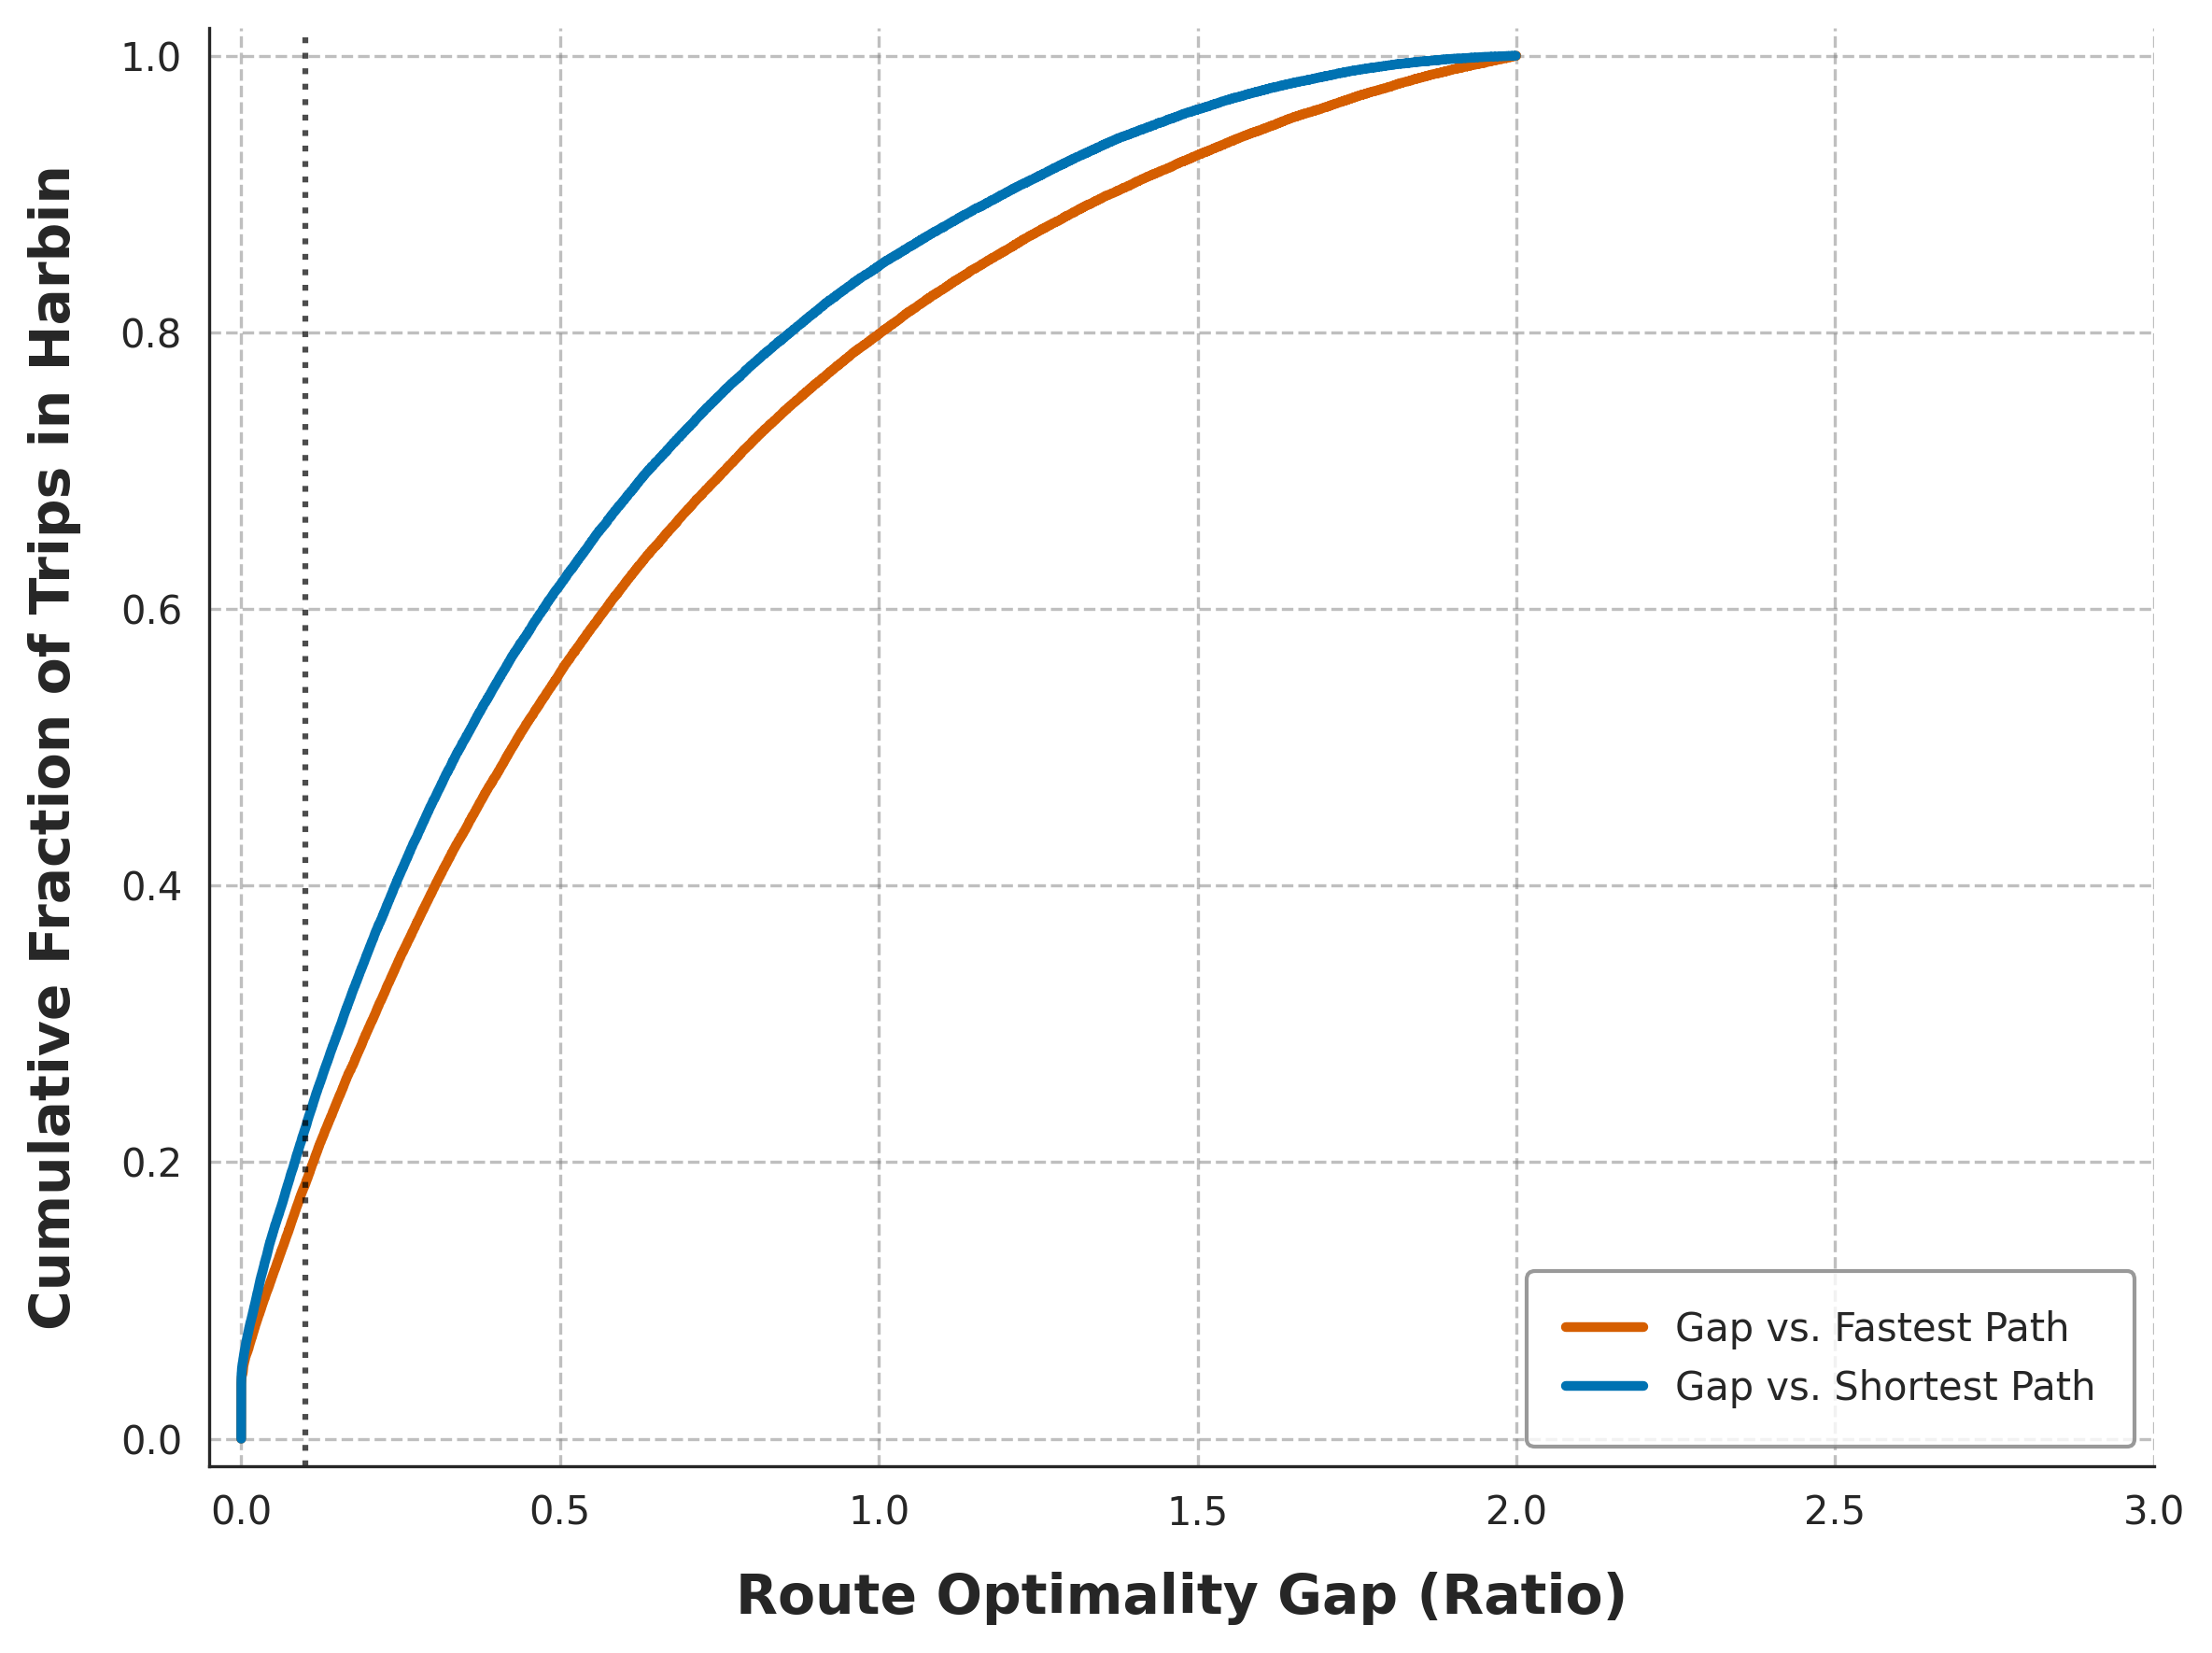

In [12]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'axes.labelsize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})
sns.set_style("white")

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.ecdfplot(data=gap_fastest, label='Gap vs. Fastest Path', 
             color='#D55E00', linewidth=2.5, ax=ax)
sns.ecdfplot(data=gap_shortest, label='Gap vs. Shortest Path', 
             color='#0072B2', linewidth=2.5, ax=ax)

place_name = "Harbin" # Replace with your variable
ax.set_ylabel(f'Cumulative Fraction of Trips in {variables.place_name.capitalize()}', weight='bold', labelpad=10)

ax.set_xlabel('Route Optimality Gap (Ratio)', weight='bold', labelpad=10)

ax.set_xlim(-0.05, 3.0) 
ax.set_ylim(-0.02, 1.02)

ax.grid(True, linestyle='--', alpha=0.5, color='gray')
sns.despine(trim=False)
ax.legend(loc='lower right', frameon=True, edgecolor='gray', borderpad=1)

# Add a reference line (e.g., showing what percentage of trips are perfectly optimal or within 10%)
ax.axvline(0.1, color='black', linestyle=':', linewidth=1.5, alpha=0.7)

# --- 5. SAVE ---
plt.tight_layout()
# plt.savefig('optimality_gap_paper_ready.pdf', format='pdf', bbox_inches='tight')
plt.show()